In [ ]:
# Mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import Libraries
from pathlib import Path
import os.path

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
# # Matthew specific path
# image_dir = Path('/content/drive/.shortcut-targets-by-id/164ydkAFLOFRw4F4nq-9O9jU3w6-wGZk6/images')

In [ ]:
# Shlok specific path
image_dir = Path('/content/drive/.shortcut-targets-by-id/164ydkAFLOFRw4F4nq-9O9jU3w6-wGZk6/images')

In [ ]:
# Import Images
filepaths = list(image_dir.glob(r'**/*.jpg'))
labels = list(map(lambda x: os.path.split(os.path.split(x)[0])[1], filepaths))

filepaths = pd.Series(filepaths, name='Filepath').astype(str)
labels = pd.Series(labels, name='Label')

images = pd.concat([filepaths, labels], axis=1)

# Get all images.
num_samples = len(images)
image_df = images.sample(n=num_samples, random_state=1).reset_index(drop=True)

print(f"Selected {len(image_df)} images for processing.")

Selected 101014 images for processing.


In [ ]:
# Subset Dataset to only 21 outputs
label_counts = image_df['Label'].value_counts()
num_classes_to_remove = int(len(label_counts) * 0.8)

# Get the labels with the lowest counts
labels_to_remove = label_counts.nsmallest(num_classes_to_remove).index.tolist()

# Filter image_df to exclude these labels
filtered_image_df = image_df[~image_df['Label'].isin(labels_to_remove)]

print(f"Original number of images: {len(image_df)}")
print(f"Number of classes removed: {num_classes_to_remove}")
print(f"Number of classes kept: {101-num_classes_to_remove}")
print(f"New total count of images after filtering: {len(filtered_image_df)}")

image_df = filtered_image_df.copy()

Original number of images: 101014
Number of classes removed: 80
Number of classes kept: 21
New total count of images after filtering: 21014


In [ ]:
# Split dataset into training and testing sets
train_df, test_df = train_test_split(
    image_df,
    train_size=0.7,
    shuffle=True,
    random_state=42)

In [ ]:
print(f'Images in training data: {train_df.shape[0]}')
print(f'Images in testing data: {test_df.shape[0]}')

Images in training data: 14709
Images in testing data: 6305


##Data Preprocessing

In [ ]:
train_data = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2)

In [ ]:
test_data = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255)

In [ ]:
#Resize images in train, test and validation
train_images = train_data.flow_from_dataframe(
  dataframe=train_df,
  x_col='Filepath',
  y_col='Label',
  target_size=(224, 224),
  color_mode='rgb',
  class_mode='categorical',
  batch_size=32,
  shuffle=True,
  seed=42,
  subset='training'
)

Found 11768 validated image filenames belonging to 21 classes.


In [ ]:
val_images = train_data.flow_from_dataframe(
  dataframe=train_df,
  x_col='Filepath',
  y_col='Label',
  target_size=(224, 224),
  color_mode='rgb',
  class_mode='categorical',
  batch_size=32,
  shuffle=True,
  seed=42,
  subset='validation'
)

Found 2941 validated image filenames belonging to 21 classes.


In [ ]:
test_images = test_data.flow_from_dataframe(
  dataframe=test_df,
  x_col='Filepath',
  y_col='Label',
  target_size=(224, 224),
  color_mode='rgb',
  class_mode='categorical',
  batch_size=32,
  shuffle=False
)

Found 6305 validated image filenames belonging to 21 classes.


##Custom CNN architecture starts here

In [ ]:
#Model Architecture
inputs = keras.Input(shape=(224, 224, 3))

x = layers.Conv2D(filters=32, kernel_size=3, activation='relu')(inputs)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Flatten()(x)
x = layers.Dropout(rate=0.5)(x)
x = layers.Dense(units=512, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(rate=0.3)(x)

outputs = layers.Dense(units=21, activation='softmax')(x)
model = keras.Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,874,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 21)             │        10,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,278,037 (73.54 MB)

 Trainable params: 19,276,053 (73.53 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Train Model on Training Data
history = model.fit(
    train_images,
    validation_data=val_images,
    epochs=10,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True)])

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 10108s 27s/step - accuracy: 0.1608 - loss: 3.2770 - val_accuracy: 0.0738 - val_loss: 4.7772
Epoch 2/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 1478s 4s/step - accuracy: 0.3252 - loss: 2.3089 - val_accuracy: 0.2958 - val_loss: 2.4852
Epoch 3/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 1485s 4s/step - accuracy: 0.4199 - loss: 1.9152 - val_accuracy: 0.3295 - val_loss: 2.2506
Epoch 4/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 1443s 4s/step - accuracy: 0.5520 - loss: 1.4981 - val_accuracy: 0.2360 - val_loss: 2.9330
Epoch 5/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 1434s 4s/step - accuracy: 0.6455 - loss: 1.1455 - val_accuracy: 0.2445 - val_loss: 2.9913
Epoch 6/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 1432s 4s/step - accuracy: 0.7571 - loss: 0.8014 - val_accuracy: 0.3873 - val_loss: 2.2773


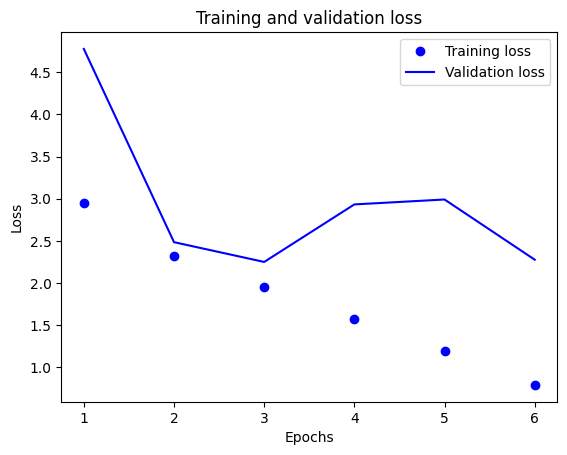

In [ ]:
## Loss Graphs
history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
acc = history_dict['accuracy']

# Define the lenght of the x axis
epochs = range(1, len(acc) + 1)

# Plot each metric and format the graph
plt.plot(epochs, loss_values, 'bo', label='Training loss')      # “bo” is for “blue dot.”
plt.plot(epochs, val_loss_values, 'b', label='Validation loss') # “b” is for “solid blue line.”
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Print the graph.
plt.show()

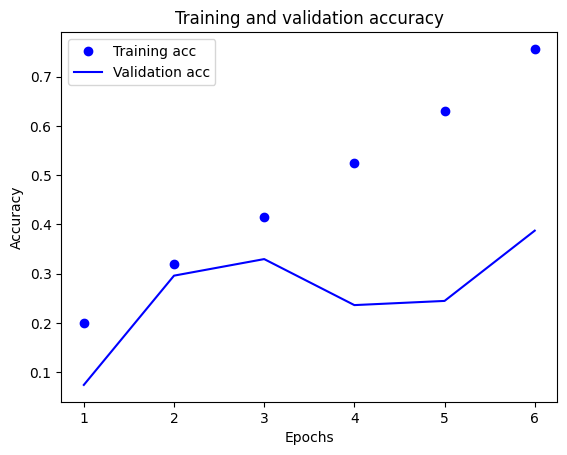

In [ ]:
## Accuracy Graphs
plt.clf()

# First, store the metrics into different objects
val_acc_values = history_dict['val_accuracy']

# Plot each metric and format the graph
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc_values, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Print the graph.
plt.show()

In [ ]:
results = model.evaluate(test_images, verbose=0)
print("Test Accuracy: {:.2f}%".format(results[1] * 100))

Test Accuracy: 34.26%


In [ ]:
model.save('food_detection_model(scratch).keras')